1. What is Boosting in Machine Learning? Explain how it improves weak
learners.
  - Boosting is a technique used to minimize the error by training many weak learners sequentially.
  - Each weak learner increases the weight of the error and decrease weight of correct, then send it to next weak learner.

2. What is the difference between AdaBoost and Gradient Boosting in terms
of how models are trained?
  - AdaBoost
    - Each new model focuses more on misclassified samples.
    - Uses sample re-weighting.
    - Final model = weighted vote of all weak learners.
  - Gradient Boosting
    - Each new model fits the residual errors (gradients) of the previous model.
    - Uses gradient descent on a loss function.
    - Final model = sum of models.

3. How does regularization help in XGBoost?
  - Penalizes complex trees so the model doesn't memorize data.
  - Prevents overfitting.

4.  Why is CatBoost considered efficient for handling categorical data?
  - Because it handles categorical data without doing one hot encoding.

5. What are some real-world applications where boosting techniques are
preferred over bagging methods?
  - Fraud detection
  - Credit scoring & loan default prediction
  - Search ranking & recommendation systems
  - Medical diagnosis

In [2]:
#  6: Write a Python program to:
# ● Train an AdaBoost Classifier on the Breast Cancer dataset
# ● Print the model accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9736842105263158

In [3]:
# 7:  Write a Python program to:
# ● Train a Gradient Boosting Regressor on the California Housing dataset
# ● Evaluate performance using R-squared score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

0.7756446042829697

In [4]:
# 8: Write a Python program to:
# ● Train an XGBoost Classifier on the Breast Cancer dataset
# ● Tune the learning rate using GridSearchCV
# ● Print the best parameters and accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier()
params = {"learning_rate": [0.1, 0.2, 0.5, 1]}
grid = GridSearchCV(model, params, cv=5)
grid.fit(X_train, y_train)

y_pred = grid.best_estimator_.predict(X_test)

print(grid.best_params_)
print(accuracy_score(y_test, y_pred))

{'learning_rate': 1}
0.956140350877193


In [5]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


<Axes: >

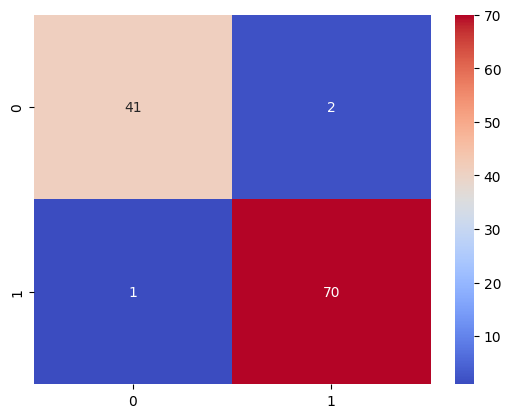

In [7]:
# 9: Write a Python program to:
# ● Train a CatBoost Classifier
# ● Plot the confusion matrix using seaborn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

model.predict(X_test)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="coolwarm")

In [ ]:
# 10: You're working for a FinTech company trying to predict loan default using
# customer demographics and transaction behavior.
# The dataset is imbalanced, contains missing values, and has both numeric and
# categorical features.
# Describe your step-by-step data science pipeline using boosting techniques:
# ● Data preprocessing & handling missing/categorical values
# ● Choice between AdaBoost, XGBoost, or CatBoost
# ● Hyperparameter tuning strategy
# ● Evaluation metrics you'd choose and why
# ● How the business would benefit from your model

- XGBoost and CatBoost can handle missing values.
- CatBoost can handle categorical features without one hot encoding.
- I will choose CatBoost, it has hyperparameter to handle class imbalance.
- For Hyperparameter tuning, i will use GridSearchCV.
- I will choose classification report for classification model to get whole report of model.
- I will choose R2 score and Adjusted R2 score for regression model, it explains how much variance happened by the features.
- The business would enter customer's demographic and transaction behavior, then model would predict what amount of loan should be given on maximum.